# Prepare the features

- [X] BOP features arrangement and averagings
- [O] Library Features arrangement ad averaging
  average per polihedra.
  average per structure.
  atoms in each polyhedra.
- [X] Matminer features cleanup (decide min, max or avg)
- clear feature list from correlations
- outlier detection based on features
- Feature Distribution plots

# Included averages

- moments of the total density of states :  

$$ m_0^i = \left( \sum_{j} m_j^i \right)/N_{atoms} $$

- CP averaged moments, norm to total number of atoms:

$$ 
   m_{CP}^i =  \left( \sum_{j \in CP} m_j^i \right)/N_{atoms}
$$ 

- CP averaged moments, norm atoms in CP:

$$ 
   m_{CP}^i =  \left( \sum_{j \in CP} m_j^i \right)/N_{CP}
$$ 

# but I should also include:

- correlation matrices for pair of sets

 - input : features dataframes from prev steps
 - output: clean features dataframes into picles

In [1]:
from Tools.DatasetTools.Commoms import *
from Tools.DatasetTools import GeneralFeaturizer as gf
dataset = 'Fe-Mo' #'Fe-Mo' #'Cr-Co-W'
NameForFile = 'FeMo'
descriptorlocation = os.path.join(dataset, 'Descriptors')
system = dataset.replace('-','')
sys.path.insert(0, '/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/')
from BopFoxFeaturizer.Featurizer import Featurizer

In [2]:
import seaborn as sns

In [3]:
plt.rc('figure', figsize=(18, 8))
plt.rc('font', size=26)
plt.rc('xtick', labelsize=26)
plt.rc('ytick', labelsize=26)
plt.rc('axes', labelsize=30)
from matplotlib.lines import Line2D

In [4]:
CNListLocation = os.path.join(descriptorlocation,'CNList.pkl')
CNList = pd.read_pickle(CNListLocation)

In [5]:
from Tools.PredictionTools.MakeAtomsOjects import make_all_atoms_objects, permutate

In [6]:
binaryr = permutate('R', 2, 11)

In [7]:
atoms_objects_file = 'Fe-Mo/Atomsobjects/R_structures.pkl'

In [8]:
if os.path.exists(atoms_objects_file):
    AtomsObjects = pd.read_pickle(atoms_objects_file)
else:
    AtomsObjects = make_all_atoms_objects(binaryr)
    AtomsObjects = AtomsObjects.to_frame()
    AtomsObjects.columns = ['atoms']
    AtomsObjects.to_pickle(atoms_object_file)

In [9]:
RBS = AtomsObjects

In [10]:
RBS['num_atoms'] = RBS.atoms.map(len)

In [11]:
RBS[['Fe', 'Mo']] = pd.DataFrame.from_dict(
    RBS.atoms.map(lambda a: pd.Series(a.symbols).value_counts().to_dict()).to_dict(),
    orient = 'index'
).fillna(0)

# EASY FEATURES 

In [12]:
RBS['Fe_pv'] = RBS['Fe'] / RBS['num_atoms']
RBS['Mo_sv'] = 1 - RBS['Fe_pv']
RBS['Mag'] = 0 #NM
RBS['Structure'] = 4

In [13]:
RBS.index += '.NM'

In [14]:
RBS

,atoms,num_atoms,Fe,Mo,Fe_pv,Mo_sv,Mag,Structure
Fe_pv53.R-AAAAAAAAAAA.NM,"(Atom('Fe', [5.5758179773241885, 5.09570158339...",53,53.0,0.0,1.000000,0.000000,0,4
Fe_pv47Mo_sv6.R-AAAAAAAAAAB.NM,"(Atom('Fe', [5.599079257515289, 5.116959906890...",53,47.0,6.0,0.886792,0.113208,0,4
Fe_pv51Mo_sv2.R-AAAAAAAAABA.NM,"(Atom('Fe', [5.583593282160754, 5.102807380847...",53,51.0,2.0,0.962264,0.037736,0,4
Fe_pv45Mo_sv8.R-AAAAAAAAABB.NM,"(Atom('Fe', [5.606790225019939, 5.124006906896...",53,45.0,8.0,0.849057,0.150943,0,4
Fe_pv47Mo_sv6.R-AAAAAAAABAA.NM,"(Atom('Fe', [5.599079257515289, 5.116959906890...",53,47.0,6.0,0.886792,0.113208,0,4
...,...,...,...,...,...,...,...,...
Fe_pv6Mo_sv47.R-BBBBBBBBABB.NM,"(Atom('Mo', [5.753096403345798, 5.257715113941...",53,6.0,47.0,0.113208,0.886792,0,4
Fe_pv8Mo_sv45.R-BBBBBBBBBAA.NM,"(Atom('Mo', [5.745773392292503, 5.251022664659...",53,8.0,45.0,0.150943,0.849057,0,4
Fe_pv2Mo_sv51.R-BBBBBBBBBAB.NM,"(Atom('Mo', [5.767686757020587, 5.271049137510...",53,2.0,51.0,0.037736,0.962264,0,4
Fe_pv6Mo_sv47.R-BBBBBBBBBBA.NM,"(Atom('Mo', [5.753096403345798, 5.257715113941...",53,6.0,47.0,0.113208,0.886792,0,4


In [15]:
def get_nelem(a):
    return len(np.unique(a.get_chemical_symbols()))

In [16]:
RBS['nelem'] = RBS['atoms'].map(get_nelem)

In [17]:
RBS['nelem']

Fe_pv53.R-AAAAAAAAAAA.NM          1
Fe_pv47Mo_sv6.R-AAAAAAAAAAB.NM    2
Fe_pv51Mo_sv2.R-AAAAAAAAABA.NM    2
Fe_pv45Mo_sv8.R-AAAAAAAAABB.NM    2
Fe_pv47Mo_sv6.R-AAAAAAAABAA.NM    2
                                 ..
Fe_pv6Mo_sv47.R-BBBBBBBBABB.NM    2
Fe_pv8Mo_sv45.R-BBBBBBBBBAA.NM    2
Fe_pv2Mo_sv51.R-BBBBBBBBBAB.NM    2
Fe_pv6Mo_sv47.R-BBBBBBBBBBA.NM    2
Mo_sv53.R-BBBBBBBBBBB.NM          1
Name: nelem, Length: 2048, dtype: int64

# CALCULATE FEATURES AND APPLY CN AVERAGE. THE ATOMS OBJECTS ARE ALREADY ORDERED !

In [18]:
from Tools.DatasetTools.GeneralFeaturizer import cn_persite
cn_persite['R']
for at in  RBS['atoms'][2]:
    print(at)
print(RBS.index[2])

Atom('Fe', [5.583593282160754, 5.102807380847488, 5.555099560384278], index=0)
Atom('Fe', [3.40353342339589, 3.112103794037992, 3.38904591128019], index=1)
Atom('Fe', [7.763653140925616, 7.093510967656983, 7.721153209488368], index=2)
Atom('Fe', [1.9111217335428652, 2.0162836649233804, 6.851198408955685], index=3)
Atom('Fe', [6.855779526133419, 1.5767594813539874, 2.292857577413509], index=4)
Atom('Fe', [2.473943886880756, 6.680704647165757, 2.0341080987140243], index=5)
Atom('Fe', [9.256064830778644, 8.189331096771598, 4.259000711812871], index=6)
Atom('Fe', [4.311407038188091, 8.628855280340987, 8.817341543355047], index=7)
Atom('Fe', [8.693242677440754, 3.5249101145292197, 9.076091022054529], index=8)
Atom('Fe', [2.432968727280905, 4.18035126210633, 7.496463148171309], index=9)
Atom('Fe', [7.4475578529956294, 1.9532439225780034, 4.496678053384418], index=10)
Atom('Fe', [4.687891179042978, 7.182276192693374, 2.499807946289788], index=11)
Atom('Fe', [8.734217837040603, 6.0252634995886

# Load Features 

In [19]:
model = '0.7projections_os'

In [20]:
results_pickle = os.path.join(descriptorlocation, f'Rstructures_FeMo_initial_{model}_table_WUBIND_16.pkl')

In [21]:
R_BOPS = pd.read_pickle(results_pickle)

In [22]:
R_BOPS.index += '.NM'

In [23]:
specialcolumns =['U_bind','U_bond_atom']#, 'U_bond_atom_list'] 
averaged_bop_file = os.path.join(descriptorlocation,'CNAV_'+os.path.basename(results_pickle))

In [24]:
CNList = pd.Series([cn_persite['R']]*len(R_BOPS), index=R_BOPS.index)

In [25]:
featurescnav = {}
if os.path.exists(averaged_bop_file):
    featurescnav[model] = pd.read_pickle(averaged_bop_file).astype(float)  # for some reason some values are objects
else:
    columnstoexpand = R_BOPS.columns.drop(specialcolumns)
    df = gf.array_expansions(R_BOPS, columnstoexpand)
    ThisCoordination = CNList[R_BOPS.index]
    df = gf.featurize_dataframe(df, ThisCoordination)
    shape_factors = gf.get_shape_factors(df)
    featurescnav[model] = pd.concat([R_BOPS[specialcolumns[:-1]], df, shape_factors],  axis=1)
    featurescnav[model].to_pickle(averaged_bop_file)

In [26]:
featurescnav[model].index += '.NM'

In [27]:
RBS.columns

Index(['atoms', 'num_atoms', 'Fe', 'Mo', 'Fe_pv', 'Mo_sv', 'Mag', 'Structure',
       'nelem'],
      dtype='object')

In [28]:
featurescnav[model][['Structure', 'Mag']] = RBS[['Structure', 'Mag']]

# LOAD MODELS 

In [29]:
from Tools.DatasetTools.MLConveniences import filter_features

In [30]:
import joblib
import pickle

In [31]:
regressor_file = os.path.join(dataset, 'results', f'voting_regressor_KernelRidge.pkl')

In [32]:
voting_regressor = joblib.load(regressor_file)

# Prediction ! 

In [33]:
combi = ('Kernel Ridge', '0.7 Projections OS BOP')

In [34]:
Prediction_Values = pd.Series(voting_regressor[combi].predict(featurescnav[model]), index=featurescnav[model].index)

In [35]:
Prediction_Values

Fe_pv53.R-AAAAAAAAAAA.NM          0.191107
Fe_pv47Mo_sv6.R-AAAAAAAAAAB.NM    0.054539
Fe_pv51Mo_sv2.R-AAAAAAAAABA.NM    0.107587
Fe_pv45Mo_sv8.R-AAAAAAAAABB.NM    0.055731
Fe_pv47Mo_sv6.R-AAAAAAAABAA.NM    0.052910
                                    ...   
Fe_pv6Mo_sv47.R-BBBBBBBBABB.NM    0.276074
Fe_pv8Mo_sv45.R-BBBBBBBBBAA.NM    0.342576
Fe_pv2Mo_sv51.R-BBBBBBBBBAB.NM    0.318736
Fe_pv6Mo_sv47.R-BBBBBBBBBBA.NM    0.324531
Mo_sv53.R-BBBBBBBBBBB.NM          0.324671
Length: 2048, dtype: float64

In [36]:
bag_of_predictions = []
for name, estimator in voting_regressor[combi].named_estimators_.items():
    this_prediction = pd.Series(estimator.predict(featurescnav[model]), index = featurescnav[model].index)
    bag_of_predictions.append(this_prediction)

In [37]:
bag_of_predictions = pd.DataFrame(bag_of_predictions).transpose()

In [38]:
ERR = bag_of_predictions.std(axis=1)

In [39]:
BS = pd.read_pickle('Fe-Mo/FullyCuratedParsedBriefSummary.pkl')

In [40]:
calcs_R = BS[['Fe_pv','EF_nmhcp']].query('index.str.contains("R-")')

Text(0.5, 0, '$\\Delta E_f $(eV/at)')

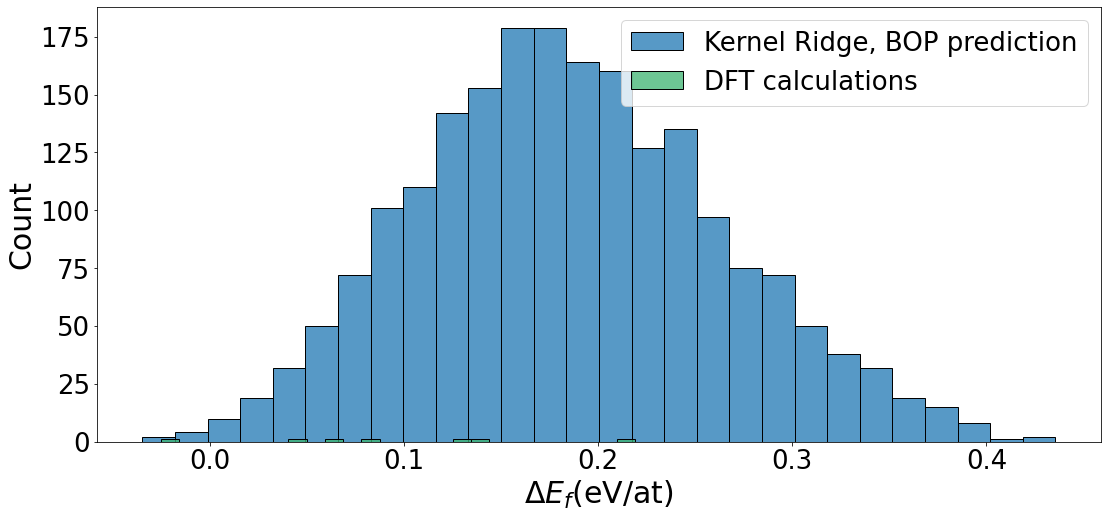

In [41]:
ax = sns.histplot(Prediction_Values, label = 'Kernel Ridge, BOP prediction')
ax = sns.histplot(calcs_R['EF_nmhcp'] , label = 'DFT calculations', binrange = [Prediction_Values.min(), Prediction_Values.max()], bins = 50, color = 'mediumseagreen')
ax.legend()
ax.set_xlabel(r'$\Delta E_f $(eV/at)')

Text(0, 0.5, '$\\Delta E_f$ (eV/atom)')

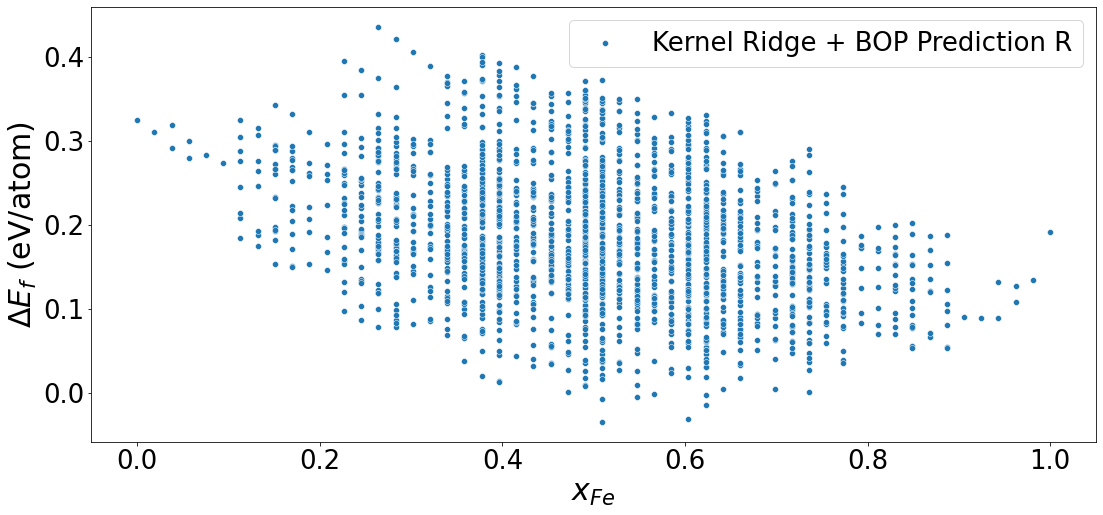

In [42]:
ax = sns.scatterplot(x = RBS['Fe_pv'], y = Prediction_Values, label = 'Kernel Ridge + BOP Prediction R')
ax.set_xlabel(r'$x_{Fe}$')
ax.set_ylabel(r'$\Delta E_f$ (eV/atom)')

In [43]:
Prediction_Values.to_pickle(os.path.join(dataset, 'results', 'R_structures_Predicted_EF_nmhcp.pkl'))

In [44]:
RBS['EF_nmhcp'] = Prediction_Values

# Recover learning prediction 

In [45]:
ModelName = 'Kernel Ridge'

In [46]:
predictedBS = pd.read_pickle(os.path.join(dataset, 'results', f'{dataset}_{ModelName}_PredictedBS.pkl'))

In [47]:
predictedBS

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,EF_nmhcp_SOAP_specific,EF_nmhcp_atomic,EF_nmhcp_dataset,EF_nmhcp_0.7 Projections OS BOP no CNAV,EF_nmhcp_Canonical BOP no CNAV,EF_nmhcp_dataset no CNAV,EF_nmhcp_atomic no CNAV,EF_nmhcp_SOAP_specific no CNAV,EF_nmhcp_ACE no CNAV,EF_nmhcp_ACE
Fe_pv8.A15.FM,bulk A15.FM,11.558019 A,-8.169759,91.497861 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,...,0.075020,0.184100,0.154339,0.111518,0.162329,-0.104316,-0.058467,0.105638,0.099732,0.082403
Fe_pv12.C14.FM,bulk C14.FM,12.119019 A,-8.105991,102.152576 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,...,0.162849,0.183492,0.233378,0.165492,0.223613,-0.104316,-0.058467,0.159902,0.164327,0.193749
Fe_pv24Mo_sv5.chi-BBAA.FM,bulk chi-BBAA.FM,11.926180 A,-8.658669,124.301732 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,0.057646,0.179214,0.033902,0.040570,0.038896,-0.068739,-0.058467,0.055606,0.033585,0.040303
Fe_pv25Mo_sv4.chi-ABAA.FM,bulk chi-ABAA.FM,11.874474 A,-8.560894,134.837320 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,0.069785,0.174336,0.071499,0.063622,0.071981,-0.075854,-0.058467,0.076971,0.059455,0.062617
Fe_pv24.C36.FM,bulk C36.FM,12.049606 A,-8.109714,150.452690 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,...,0.164994,0.177627,0.246713,0.176193,0.360934,-0.104316,-0.058467,0.177636,0.189515,0.202361
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv25Mo_sv4.chi-ABAA.NM,bulk chi-ABAA,11.072302 A,-8.505552,279.868523 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,0.072477,0.174336,0.071499,0.130966,0.071981,-0.075854,-0.058467,0.111858,0.080050,0.079744
Fe_pv16Mo_sv8.C36-BBAAA.NM,bulk C36-BBAAA,12.044661 A,-9.117739,281.820517 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,-0.022347,0.216295,0.028491,0.014767,-0.068925,-0.035533,-0.058467,-0.010970,-0.007164,-0.008838
Fe_pv8Mo_sv4.C14-BAA.NM,bulk C14-BAA,12.031891 A,-9.133101,282.397960 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,-0.021326,0.215992,-0.044446,-0.003078,-0.002473,-0.035533,-0.058467,-0.026062,-0.034829,-0.014629
Fe_pv4.fcc-cubic.NM,bulk fcc-cubic,10.248696 A,-8.104999,283.740438 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,...,0.029504,0.147302,0.118489,0.120417,0.061582,-0.104316,-0.058467,0.117864,0.127843,0.110598


# New Convex Hulls 

In [48]:
from Tools.DatasetTools.Tools import Plotting, PlottingChulls
P = Plotting()

In [49]:
target_case = 'EF_nmhcp'

In [50]:
from scipy.spatial import ConvexHull

In [51]:
points = RBS[['Fe_pv', 'EF_nmhcp']]

In [52]:
PhasesBS = {'': {'R' : RBS}}

In [76]:
def plot_chull(
    thePhasesBS,
    theproperty, 
    mag_list = None,
    plot_points = True,
    plot_only = [], 
    line_styles = '-',
    figs_mag = {},
    ax_mag = {},
    components = ['Fe_pv', 'Mo_sv']
):
    palettename = 'tab20c'
    for mag, PhaseBS in  thePhasesBS.items():
        if mag not in mag_list:
            continue
        points = P.get_x_ef_points(PhaseBS, components, property=theproperty)
        chulls =  P.get_convex_hulls(PhaseBS, components, getproperty = theproperty, return_points = False)
        palette = PlottingChulls.make_palette_forlist(PhaseBS.keys())
        if len(plot_only)>0:
            palette = {name: color for name, color in palette.items() if name in plot_only} 
        if mag not in figs_mag.keys():
            figs_mag[mag],  ax_mag[mag] = plt.subplots(figsize=(12,8))
        fig = figs_mag[mag]
        ax = ax_mag[mag]
        labels=[]
        handles = []
        for phase, chull in chulls.items():
            if len(plot_only) > 0:
                if phase not in plot_only:
                    continue
            for visible_facet in chull.simplices[chull.good]:
                if plot_points:
                    ax.plot(points[phase][components[0]] , points[phase][theproperty], 'o', color = palette[phase])
                l = ax.plot(chull.points[visible_facet,0], chull.points[visible_facet,1],line_styles,  color=palette[phase], linewidth = 4, markersize=10, markeredgecolor='k')
            handles.append(l[0])
            labels.append(phase)
        leg = ax.legend(handles, labels, bbox_to_anchor=(1.01,1), title=mag)
        setlw = [ha.set_linewidth(5) for ha in leg.get_lines() ]
        ax.set_ylabel(r'$\Delta E _f$ (eV/atom)')
        ax.set_xlabel(rf'$x_{{{components[0]}}}$')
        fig.tight_layout()
        figs_mag[mag] = fig
        ax_mag[mag] = ax
    return figs_mag, ax_mag 

In [77]:
predictedPhaseBS =  {
    '': {'R':  predictedBS.query('index.str.contains("R-")')}
}

({'': <Figure size 1200x800 with 1 Axes>},
 {'': <AxesSubplot:xlabel='$x_{Fe_pv}$', ylabel='$\\Delta E _f$ (eV/atom)'>})

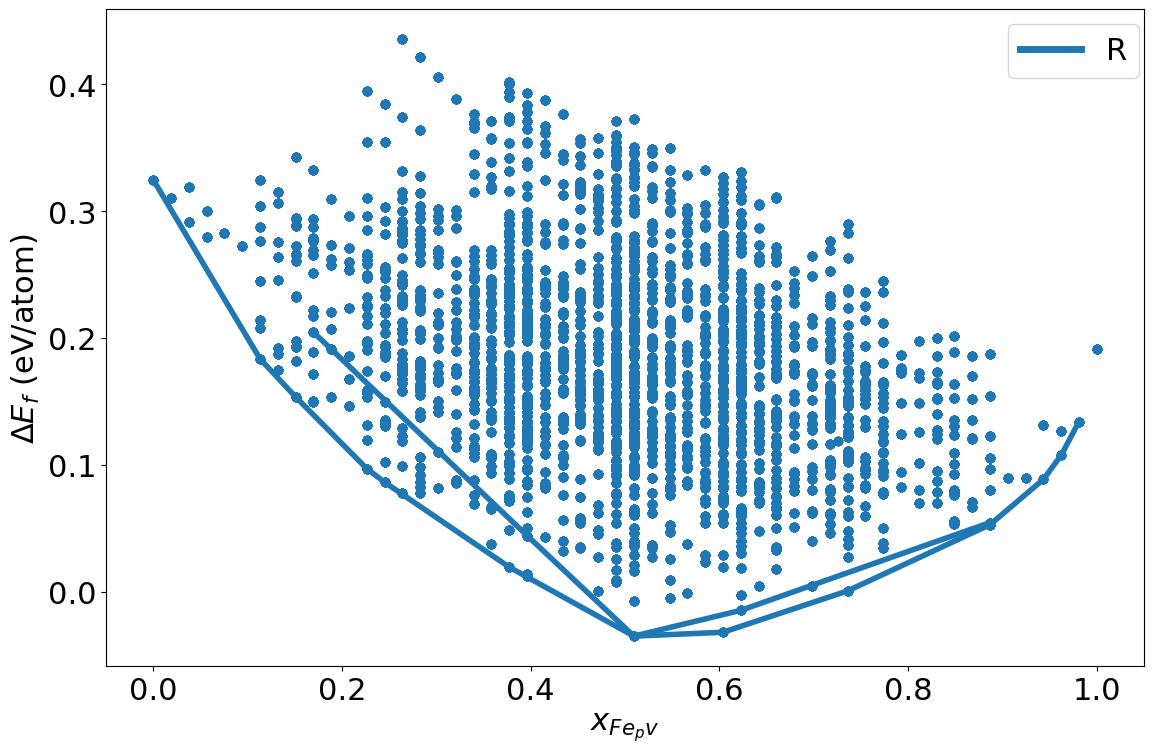

In [80]:
tfig, tax = plot_chull(PhasesBS, 'EF_nmhcp', mag_list=[''], plot_points=True, figs_mag={}, ax_mag={})
plot_chull(predictedPhaseBS, 'EF_nmhcp_0.7 Projections OS BOP', mag_list=[''], plot_points=True, figs_mag=tfig, ax_mag=tax)

In [52]:
def plot_chull(thepoints, theviewpoint = None, x_ = 'Fe_pv', y_ = 'EF_nmhcp', fig=None, ax = None, visible = ''):
    if fig is None:
        fig, ax = plt.subplots()
    if theviewpoint is not None:
        viewpoint = pd.DataFrame([theviewpoint], columns = [x_, y_], index= ['viewpoint'])
        w_viewpoint = pd.concat([ thepoints, viewpoint,] , axis = 0)
    chull = ConvexHull(w_viewpoint, qhull_options = f'QG{visible}{w_viewpoint.shape[0]-1}')
    ax = sns.scatterplot(data = thepoints, x= x_, y = y_, ax = ax)
    for (facet, isgood) in zip(chull.simplices, chull.good):
        if isgood:
            ax.plot(points.iloc[facet, 0], points.iloc[facet,1], color='k')
    return fig, ax

> /tmp/ipykernel_7345/2532805202.py(6)plot_chull()
      4     if theviewpoint is not None:
      5         pdb.set_trace()
----> 6         viewpoint = pd.DataFrame([theviewpoint], columns = [x_, y_], index= ['viewpoint'])
      7         w_viewpoint = pd.concat([ thepoints, viewpoint,] , axis = 0)
      8     chull = ConvexHull(w_viewpoint, qhull_options = f'QG{visible}{w_viewpoint.shape[0]-1}')



ipdb>  q


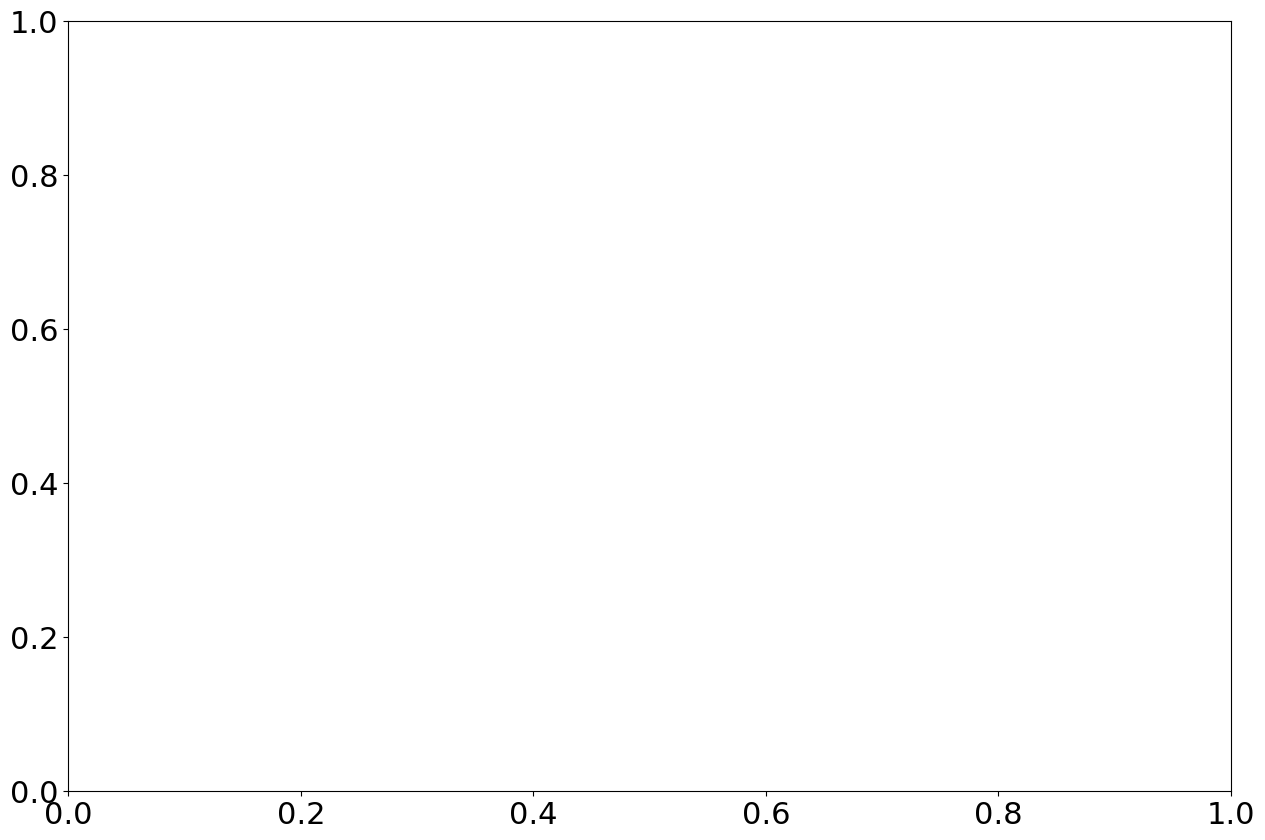

In [53]:
fig, ax =  plot_chull(points, [0.5, 0.6], visible='-')

 to compare with dft calculations, I need the convex hull of the non-curated briefsummary 

In [ ]:
BS = pd.read_pickle('Fe-Mo/FurtherCuratedParsedBriefSummary.pkl')

In [ ]:
dft_points  = BS[['Fe_pv', 'EF_nmhcp']]#.filter('index.str.contanis("R-")')

In [ ]:
r_dft_points = dft_points.loc[dft_points.index.str.contains('mu')]

In [ ]:
fig, ax = plot_chull(r_dft_points,theviewpoint=[0.1, -0.06])

# Bopxplots 

In [ ]:
equals = RBS.index.intersection(calcs_R.index)

In [ ]:
alldata = pd.concat([RBS['Fe_pv'] , bag_of_predictions], axis = 1).loc[equals]

In [ ]:
melted = alldata.melt(id_vars='Fe_pv')

In [ ]:
sns.boxplot(data=melted, x= 'Fe_pv', y = 'value')

In [ ]:
alldata = alldata.loc[equals].melt(id_vars=['Fe_pv'])

In [ ]:
sns.scatterplot(alldata

In [ ]:
ax = sns.scatterplot(x = RBS['Fe_pv'][equals], y = Prediction[equals], label = 'Prediction for R')
sns.scatterplot(data = calcs_R, x = 'Fe_pv', y = 'EF_nmhcp', ax = ax, ls='--', err=ERR[equals])
ax.set_xlabel(r'$x_{Fe}$')
ax.set_ylabel(r'$\Delta E_f$ (eV/atom)')

In [ ]:
ax = sns.scatterplot()

Coordination Number averages

In [ ]:
PyscalFeaturesFile = os.path.join(descriptorlocation, 'CNAVPyscal.pkl')

In [ ]:
bopmodels = ['canonical', 'projections', 'projections_os']
bopfeaturesfile = {model: os.path.join(descriptorlocation, f'curated_{system}_initial_{model}_table_WUBIND_16.pkl') for model in bopmodels}

In [ ]:
PyscalFeatures = pd.read_pickle(PyscalFeaturesFile)
BopFeatures = {model: pd.read_pickle(modelfile) for model, modelfile in bopfeaturesfile.items()}
AtomicFeatures = pd.read_pickle(AtomicFeaturesFile)
CompositionFeatures = pd.read_pickle(CompositionFeaturesFile)

# Outlier detection 

I know there are outliers. It is enaugh with looking at the following plots:

In [7]:
BopFeatures['canonical']

,U_bind,U_bond_atom_list_1_0,U_bond_atom_list_1_CN12,U_bond_atom_list_1_CN13,U_bond_atom_list_1_CN14,U_bond_atom_list_1_CN15,U_bond_atom_list_1_CN16,moments_1_0,moments_1_CN12,moments_1_CN13,...,Binf_1_CN13,Binf_1_CN14,Binf_1_CN15,Binf_1_CN16,sf_0,sf_CN12,sf_CN13,sf_CN14,sf_CN15,sf_CN16
Fe_pv8Mo_sv22.sigma-BBABB.FM,-100.702297,-7.906327,-1.428383,0.000000,-6.005237,-0.472706,0.000000,1.174563,0.433709,0.000000,...,0.000000,0.660966,0.164368,0.000000,1.224171,1.311938,0.000000,1.187302,1.155462,0.000000
Fe_pv10Mo_sv20.sigma-ABBAB.FM,-78.594335,-7.771059,-1.424594,0.000000,-5.906606,-0.439859,0.000000,1.201761,0.443751,0.000000,...,0.000000,0.668575,0.166260,0.000000,1.224174,1.311938,0.000000,1.187308,1.155463,0.000000
Fe_pv4Mo_sv20.C36-ABBBB.FM,-94.449166,-8.534487,-7.595698,0.000000,0.000000,0.000000,-0.938789,1.303069,1.079142,0.000000,...,0.000000,0.000000,0.000000,0.501537,1.081732,1.156282,0.000000,0.000000,0.000000,0.901327
Fe_pv5Mo_sv24.chi-AABB.FM,-116.205661,-8.244366,-6.070495,-1.652565,0.000000,0.000000,-0.521305,1.162619,0.589668,0.434727,...,0.451346,0.000000,0.000000,0.186186,1.251703,1.437268,1.179083,0.000000,0.000000,1.006205
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM,-121.105805,-8.136275,-2.533063,0.000000,-0.844603,-0.318349,-4.440260,1.218738,0.765044,0.000000,...,0.000000,0.256809,0.124851,0.170809,1.192249,1.343509,0.000000,1.139857,0.956735,0.947607
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv3Mo_sv10.mu-ABBBA.NM,-40.035290,-8.020136,-2.520056,0.000000,-0.663807,-0.397166,-4.439107,1.265062,0.918735,0.000000,...,0.000000,0.220371,0.224323,0.222761,1.071111,1.222567,0.000000,0.902499,0.748344,1.001884
Fe_pv8Mo_sv22.sigma-BBABB.NM,-100.702297,-7.906327,-1.428383,0.000000,-6.005237,-0.472706,0.000000,1.174563,0.433709,0.000000,...,0.000000,0.660966,0.164368,0.000000,1.224171,1.311938,0.000000,1.187302,1.155462,0.000000
Fe_pv1Mo_sv3.L12-AB3.FM,-12.617373,-6.832601,-6.832601,0.000000,0.000000,0.000000,0.000000,1.063750,1.063750,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.140024,1.140024,0.000000,0.000000,0.000000,0.000000
Fe_pv8Mo_sv22.sigma-BBBBA.FM,-94.569986,-7.892530,-5.305761,0.000000,-2.136368,-0.450401,0.000000,1.174563,0.433709,0.000000,...,0.000000,0.660966,0.164368,0.000000,1.224171,1.311938,0.000000,1.187302,1.155462,0.000000


<AxesSubplot:xlabel='U_bond_atom_list_1_0', ylabel='Count'>

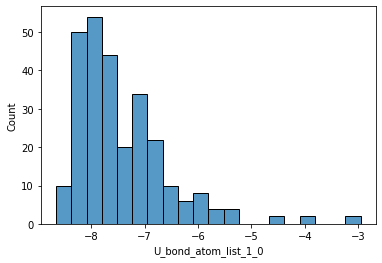

In [8]:
sns.histplot(BopFeatures['canonical']['U_bond_atom_list_1_0'])

# compiling FULL features 

In [9]:
AllFeatures = [AtomicFeatures,CompositionFeatures, BopFeatures['canonical'] ] # 

In [10]:
FullSetOfFeatures = pd.concat(AllFeatures, axis = 1)

# categorical features transformation

In [11]:
from sklearn import set_config
from sklearn.compose import make_column_selector
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import make_pipeline

In [12]:
cat_selector = make_column_selector(dtype_include=object)
categorical_features_names = cat_selector(FullSetOfFeatures)
CategoricalFeatures = FullSetOfFeatures[categorical_features_names]

In [13]:
oencoder = OrdinalEncoder()
oencoder.fit(X=CategoricalFeatures)
replace_categorical_features_values  = oencoder.transform(CategoricalFeatures)

In [14]:
FullSetOfFeatures[categorical_features_names] = replace_categorical_features_values

In [15]:
FullSetOfFeatures[categorical_features_names]

,HOMO_character,HOMO_element,LUMO_character,LUMO_element,compound possible
Fe_pv8.A15.FM,0.0,0.0,0.0,0.0,1.0
Fe_pv12.C14.FM,0.0,0.0,0.0,0.0,1.0
Fe_pv17Mo_sv12.chi-AAAB.FM,0.0,1.0,0.0,1.0,0.0
Fe_pv24Mo_sv5.chi-BBAA.FM,0.0,0.0,0.0,0.0,0.0
Fe_pv25Mo_sv4.chi-ABAA.FM,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...
Fe_pv16Mo_sv8.C36-BBAAA.NM,1.0,0.0,1.0,0.0,0.0
Fe_pv8Mo_sv4.C14-BAA.NM,1.0,0.0,1.0,0.0,0.0
Fe_pv4.fcc-cubic.NM,0.0,0.0,0.0,0.0,1.0
Fe_pv2.hcp.NM,0.0,0.0,0.0,0.0,1.0


# Fix Column Names  

In [16]:
def fix_column_name(thecolumn):
    return thecolumn.replace(' ','_')

In [17]:
columns = FullSetOfFeatures.columns

In [18]:
newcolumns = {col: fix_column_name(col) for col in columns}

In [19]:
FullSetOfFeatures.rename(columns=newcolumns, inplace=True)

In [20]:
FullSetOfFeatures

,MagpieData_minimum_Number,MagpieData_maximum_Number,MagpieData_range_Number,MagpieData_mean_Number,MagpieData_avg_dev_Number,MagpieData_mode_Number,MagpieData_minimum_MendeleevNumber,MagpieData_maximum_MendeleevNumber,MagpieData_range_MendeleevNumber,MagpieData_mean_MendeleevNumber,...,Binf_1_CN13,Binf_1_CN14,Binf_1_CN15,Binf_1_CN16,sf_0,sf_CN12,sf_CN13,sf_CN14,sf_CN15,sf_CN16
Fe_pv8.A15.FM,26.0,26.0,0.0,26.000000,0.000000,26.0,55.0,55.0,0.0,55.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fe_pv12.C14.FM,26.0,26.0,0.0,26.000000,0.000000,26.0,55.0,55.0,0.0,55.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fe_pv17Mo_sv12.chi-AAAB.FM,26.0,42.0,16.0,32.620690,7.762188,26.0,50.0,55.0,5.0,52.931034,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fe_pv24Mo_sv5.chi-BBAA.FM,26.0,42.0,16.0,28.758621,4.565993,26.0,50.0,55.0,5.0,54.137931,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fe_pv25Mo_sv4.chi-ABAA.FM,26.0,42.0,16.0,28.206897,3.804994,26.0,50.0,55.0,5.0,54.310345,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv16Mo_sv8.C36-BBAAA.NM,26.0,42.0,16.0,31.333333,7.111111,26.0,50.0,55.0,5.0,53.333333,...,0.0,0.0,0.0,0.547073,1.081733,1.156284,0.0,0.0,0.0,0.901328
Fe_pv8Mo_sv4.C14-BAA.NM,26.0,42.0,16.0,31.333333,7.111111,26.0,50.0,55.0,5.0,53.333333,...,0.0,0.0,0.0,0.530717,1.106266,1.192873,0.0,0.0,0.0,0.904120
Fe_pv4.fcc-cubic.NM,26.0,26.0,0.0,26.000000,0.000000,26.0,55.0,55.0,0.0,55.000000,...,0.0,0.0,0.0,0.000000,1.140021,1.140021,0.0,0.0,0.0,0.000000
Fe_pv2.hcp.NM,26.0,26.0,0.0,26.000000,0.000000,26.0,55.0,55.0,0.0,55.000000,...,0.0,0.0,0.0,0.000000,1.143628,1.143628,0.0,0.0,0.0,0.000000


# Unsupervised feature selection 

## Variance Threashold

remove features with low variance

TODO: for each separate set of features and save clean pickles

In [21]:
from sklearn.feature_selection import VarianceThreshold

In [22]:
selector = VarianceThreshold()

In [23]:
variance_reduced = selector.fit_transform(FullSetOfFeatures)

/scratch/AnacondaEnvironments/ml_datasets/lib/python3.9/site-packages/sklearn/feature_selection/_variance_threshold.py:104: RuntimeWarning: Degrees of freedom <= 0 for slice.
  self.variances_ = np.nanvar(X, axis=0)
/scratch/AnacondaEnvironments/ml_datasets/lib/python3.9/site-packages/sklearn/feature_selection/_variance_threshold.py:112: RuntimeWarning: All-NaN slice encountered
  self.variances_ = np.nanmin(compare_arr, axis=0)


In [24]:
selectedfeatures = selector.get_support()

In [25]:
AfterVarianceFeatures = FullSetOfFeatures.iloc[:,selectedfeatures]

In [26]:
AfterVarianceFeaturesLocation = os.path.join(descriptorlocation, 'FullSetOfFeatures.pkl')

In [27]:
FullSetOfFeatures.to_pickle(AfterVarianceFeaturesLocation)

#  Correlation based feature selection

this is not started even. 

In [28]:
CORR = AfterVarianceFeatures.corr().abs()

to facilitate higly correlations removal, I will see only the upper triangle of this simmetric matrix

In [29]:
columns = np.full((CORR.shape[0],), True, dtype=bool)

In [30]:
tri_upper_corr = CORR.where(np.triu(np.ones(CORR.shape), k=1).astype(bool))

In [31]:
to_drop = [column for column in tri_upper_corr.columns if any(tri_upper_corr[column] > 0.98)]

In [32]:
len(to_drop)

356

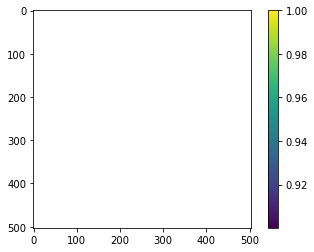

In [33]:
plt.imshow(tri_upper_corr[tri_upper_corr>0.9])
plt.colorbar()

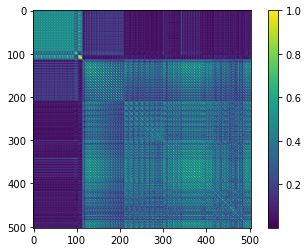

In [34]:
plt.imshow(CORR)
plt.colorbar()